## Import Important Packages

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Dataset

In [3]:
os.chdir("C:\\Hello\\GITHUB_repo\\Covid19")
df = pd.read_csv("covid.csv")

### Basic inspection

In [4]:
print("----info----")
print(df.info())
print("\n----Head----")
print(df.head())
print("\n----Description----")
print(df.describe())
print("\n----Missing Values----")
print(df.isnull().sum())

----info----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7320 entries, 0 to 7319
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          7320 non-null   object
 1   country       7320 non-null   object
 2   new_cases     7320 non-null   int64 
 3   new_deaths    7320 non-null   int64 
 4   total_cases   7320 non-null   int64 
 5   total_deaths  7320 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 343.3+ KB
None

----Head----
         date      country  new_cases  new_deaths  total_cases  total_deaths
0  2019-12-31  Afghanistan          0           0            0             0
1  2020-01-01  Afghanistan          0           0            0             0
2  2020-01-02  Afghanistan          0           0            0             0
3  2020-01-03  Afghanistan          0           0            0             0
4  2020-01-04  Afghanistan          0           0            0             0

----Descrip

Data Date Range: 2019-12-31 to 2020-03-28
Total Countries: 196

Top 10 Countries by Total Cases: 
            country  total_cases  total_deaths  fatality_rate_%
187   United States       104686          1707         1.630591
92            Italy        86498          9136        10.562094
38            China        82213          3301         4.015180
166           Spain        64059          4858         7.583634
68          Germany        48582           325         0.668972
63           France        32964          1995         6.052057
87             Iran        32332          2378         7.354942
186  United Kingdom        14543           759         5.219006
172     Switzerland        12104           197         1.627561
165     South Korea         9478           144         1.519308


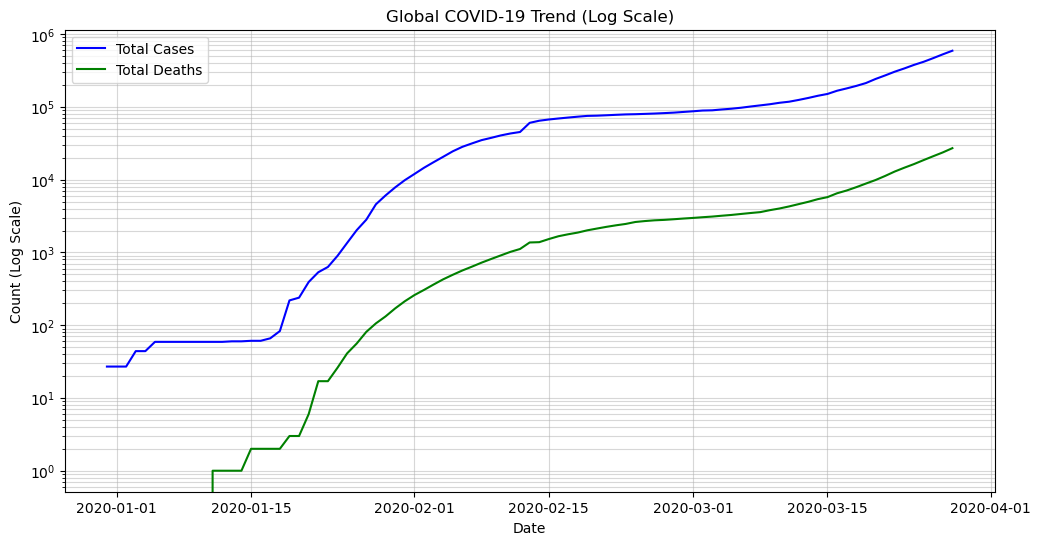

In [7]:
# 1. Covert date to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Get basic statistics
latest_date = df['date'].max()
earliest_date = df['date'].min()
num_countries = df['country'].nunique()

# 3. Create a summary of total cases and deaths by country (latest data)
# Note: Since the data is cumulative, we take the maximum value or the value at the latest date.
country_summary = df.groupby('country').agg({
    'total_cases': 'max',
    'total_deaths': 'max'
}).reset_index()

# 4. Calculate Fatality Rate
country_summary['fatality_rate_%'] = (country_summary['total_deaths'] / country_summary['total_cases']* 100).fillna(0)

# 5. Top 10 countries by total cases
top_10_cases = country_summary.sort_values(by='total_cases', ascending=False).head(10)

# 6. Global Trend Analysis
global_trend = df.groupby('date').agg({
    'new_cases' : 'sum',
    "new_deaths": "sum",
    "total_cases": "sum",
    "total_deaths": "sum"
}).reset_index()

# Plotting Global Trend
plt.figure(figsize=(12, 6))
plt.plot(global_trend['date'], global_trend['total_cases'], label='Total Cases', color="blue")
plt.plot(global_trend['date'], global_trend['total_deaths'], label='Total Deaths', color="green")
plt.yscale('log') # use log scale to see both trends clearly
plt.title("Global COVID-19 Trend (Log Scale)")
plt.xlabel("Date")
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig("global_trend.png")


# Result to print
print(f"Data Date Range: {earliest_date.date()} to {latest_date.date()}")
print(f"Total Countries: {num_countries}")
print(f"\nTop 10 Countries by Total Cases: ")
print(top_10_cases[['country', 'total_cases', 'total_deaths', 'fatality_rate_%']])

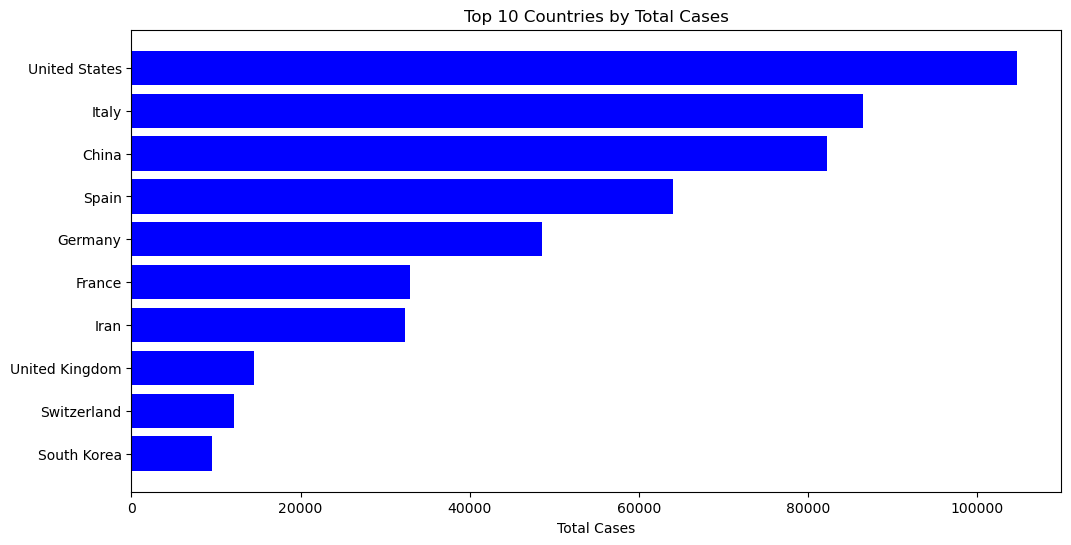

In [10]:
# Plotting 10 countries
plt.figure(figsize=(12, 6))
top_10_cases_sorted = top_10_cases.sort_values(by='total_cases', ascending=True)
plt.barh(top_10_cases_sorted['country'], top_10_cases_sorted['total_cases'], color='blue')
plt.title("Top 10 Countries by Total Cases")
plt.xlabel("Total Cases")
plt.savefig('top_10_countries.png')

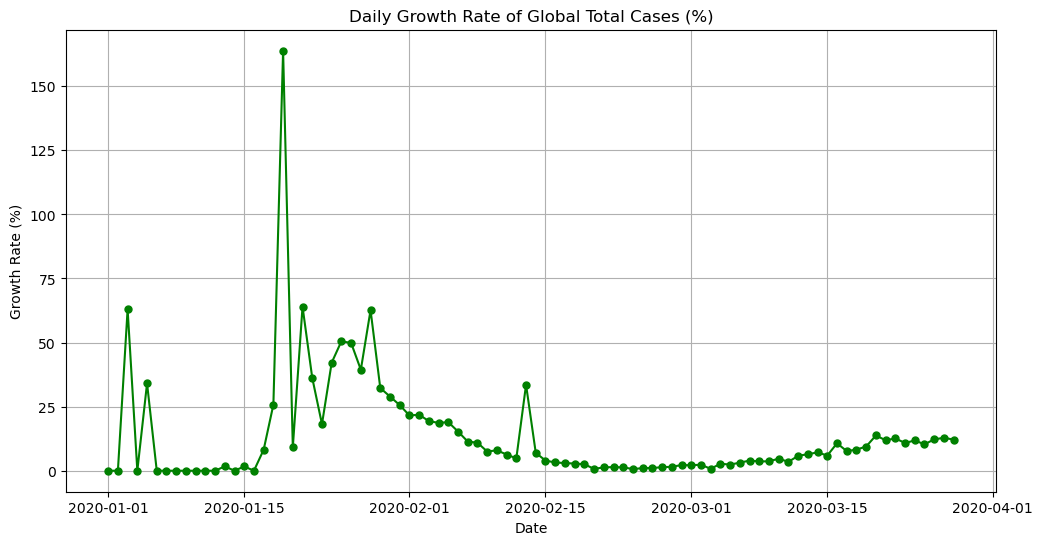

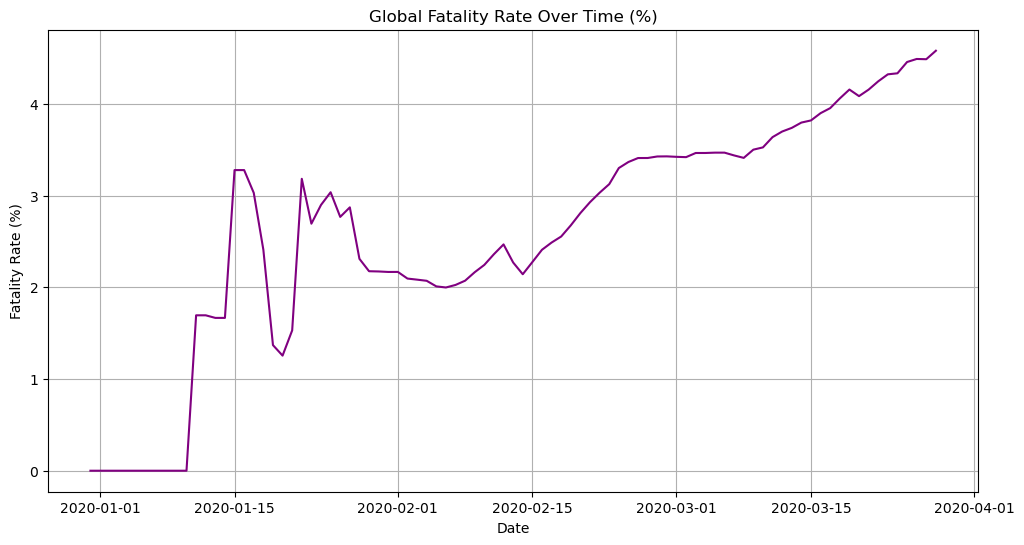

In [13]:
# 1. Cleaning: Remove negative values in new_cases 
df['new_cases'] = df['new_cases'].clip(lower=0)
df['new_deaths'] = df['new_deaths'].clip(lower=0)

# 2. Features Engineering: Daily Growth Rate for Total Cases (Global)
global_trend['growth_rate_%'] = global_trend['total_cases'].pct_change() * 100

# 3. Growth Rate Visualization
plt.figure(figsize=(12,6))
plt.plot(global_trend['date'], global_trend['growth_rate_%'], color='green', marker='o', markersize=5)
plt.title("Daily Growth Rate of Global Total Cases (%)")
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")
plt.grid(True)
plt.savefig('global_growth_rate.png')

# 4. Save cleaned and summarized dat
country_summary.to_csv("country_summary.csv", index=False)
global_trend.to_csv("global_trend.csv", index=False)

# Extra Abalysis: Fatality rate over time 
global_trend['global_fatality_rate_%'] = (global_trend['total_deaths'] / global_trend['total_cases'] * 100).fillna(0)

plt.figure(figsize=(12,6))
plt.plot(global_trend['date'], global_trend['global_fatality_rate_%'], color='purple')
plt.title("Global Fatality Rate Over Time (%)")
plt.xlabel("Date")
plt.ylabel("Fatality Rate (%)")
plt.grid(True)
plt.savefig('global_fatality_rate.png')

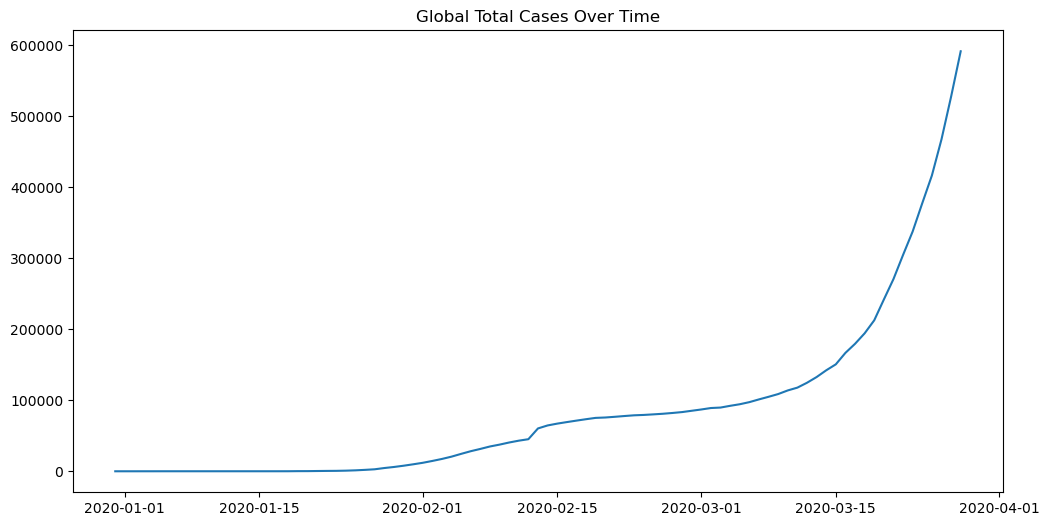

In [15]:
df['date'] = pd.to_datetime(df['date'])
df['new_cases'] = df['new_cases'].clip(lower=0)

# Calculate global daily totals
global_data = df.groupby('date').sum().reset_index()

# Calculate Fatality Rate
global_data['fatality_rate'] = (global_data['total_deaths'] / global_data['total_cases']) * 100

# Plotting
plt.figure(figsize=(12,6))
plt.plot(global_data['date'], global_data['total_cases'])
plt.title('Global Total Cases Over Time')
plt.show()